En este notebook vamos a entrenar el modelo de estimación de edad que utiliza el servicio **DE**
del sistema de pixelación de menores. El objetivo es clasificar imágenes
de caras como **menor** (<18) o **adulto** (>=18).

Vamos a entrenar **tres modelos** y compararlos para quedarnos con el más adecuado:
1. CNN desde cero
2. ResNet-50 con transferencia de conocimiento
3. ResNet-50 con transferencia + augmentation

Generamos los datasets de entrenamiento y validación a partir del dataset de caras etiquetadas por edad y prepáralos para entrenar una CNN desde cero.

In [4]:
import torch
print(torch.__version__)
print(torch.version.cuda)
print(torch.cuda.get_device_name(0))
print(torch.cuda.get_device_capability(0))
print(torch.cuda.is_available())

2.11.0+cu130
13.0
NVIDIA GeForce RTX 5080
(12, 0)
True


In [5]:
import os
import random
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler, random_split
from torchvision import models
from PIL import Image
import albumentations as A
from albumentations.pytorch import ToTensorV2
import matplotlib.pyplot as plt

DATASET_ROOT = "C:\\Users\\diego\\Documents\\dataset\\face_age"
PATH_MODELS  = "models"
BATCH_SIZE   = 32
EPOCHS       = 10
PATIENCE     = 5
LR           = 1e-4
IMG_SIZE     = (224, 224)

os.makedirs(PATH_MODELS, exist_ok=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {device}")


Dispositivo: cuda


Total imágenes : 9,778
Menores (<18)  : 3,925  (40.1%)
Adultos (>=18) : 5,853  (59.9%)


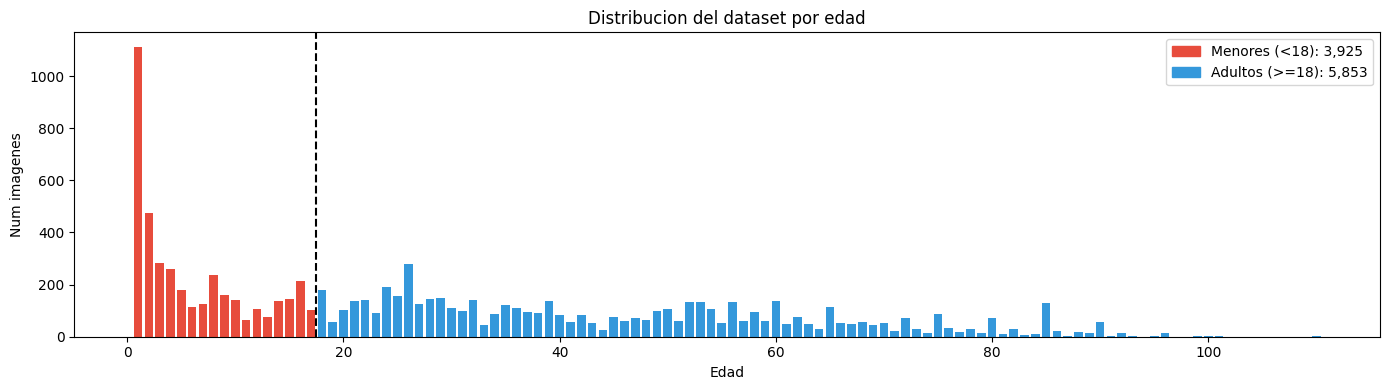

In [6]:
ages, n_minors_per_age, n_adults_per_age = [], [], []
minor_total, adult_total = 0, 0

for folder in sorted(Path(DATASET_ROOT).iterdir()):
    if not folder.is_dir():
        continue
    try:
        age = int(folder.name)
    except ValueError:
        continue
    n = sum(len(list(folder.glob(ext))) for ext in ("*.png", "*.jpg", "*.jpeg"))
    ages.append(age)
    if age < 18:
        n_minors_per_age.append(n); n_adults_per_age.append(0)
        minor_total += n
    else:
        n_minors_per_age.append(0); n_adults_per_age.append(n)
        adult_total += n

total = minor_total + adult_total
print(f"Total imágenes : {total:,}")
print(f"Menores (<18)  : {minor_total:,}  ({100*minor_total/total:.1f}%)")
print(f"Adultos (>=18) : {adult_total:,}  ({100*adult_total/total:.1f}%)")

plt.figure(figsize=(14, 4))
counts = [m + a for m, a in zip(n_minors_per_age, n_adults_per_age)]
colors = ["#e74c3c" if a < 18 else "#3498db" for a in ages]
plt.bar(ages, counts, color=colors, width=0.8)
plt.axvline(x=17.5, color="black", linestyle="--", linewidth=1.5, label="Limite 18")
plt.xlabel("Edad"); plt.ylabel("Num imagenes")
plt.title("Distribucion del dataset por edad")
plt.legend(handles=[
    plt.Rectangle((0,0),1,1, color="#e74c3c", label=f"Menores (<18): {minor_total:,}"),
    plt.Rectangle((0,0),1,1, color="#3498db", label=f"Adultos (>=18): {adult_total:,}"),
], loc="upper right")
plt.tight_layout(); plt.show()


In [7]:
class FaceAgeDataset(Dataset):
    def __init__(self, root, transform=None):
        self.samples  = []
        self.transform = transform
        for folder in sorted(Path(root).iterdir()):
            if not folder.is_dir(): continue
            try: age = int(folder.name)
            except ValueError: continue
            label = 1.0 if age < 18 else 0.0
            for ext in ("*.png", "*.jpg", "*.jpeg"):
                for img_path in folder.glob(ext):
                    self.samples.append((str(img_path), label))

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = np.array(Image.open(path).convert("RGB"))
        if self.transform:
            img = self.transform(image=img)["image"]
        return img, torch.tensor(label, dtype=torch.float32)


base_tf = A.Compose([
    A.Resize(*IMG_SIZE),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

full_ds    = FaceAgeDataset(DATASET_ROOT, transform=base_tf)
val_size   = int(len(full_ds) * 0.2)
train_size = len(full_ds) - val_size
train_ds, val_ds = random_split(full_ds, [train_size, val_size],
                                 generator=torch.Generator().manual_seed(42))

train_labels = [full_ds.samples[i][1] for i in train_ds.indices]
n_minor = int(sum(train_labels));  n_adult = len(train_labels) - n_minor
w_minor = (n_minor + n_adult) / (2 * n_minor) if n_minor > 0 else 1.0
w_adult = (n_minor + n_adult) / (2 * n_adult) if n_adult > 0 else 1.0
sample_w = [w_minor if l == 1.0 else w_adult for l in train_labels]
sampler  = WeightedRandomSampler(sample_w, num_samples=len(sample_w), replacement=True)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler, num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,   num_workers=0)

print(f"Train: {train_size:,}  Val: {val_size:,}")
print(f"Menores en train: {n_minor:,}  Adultos: {n_adult:,}")

Train: 7,823  Val: 1,955
Menores en train: 3,165  Adultos: 4,658


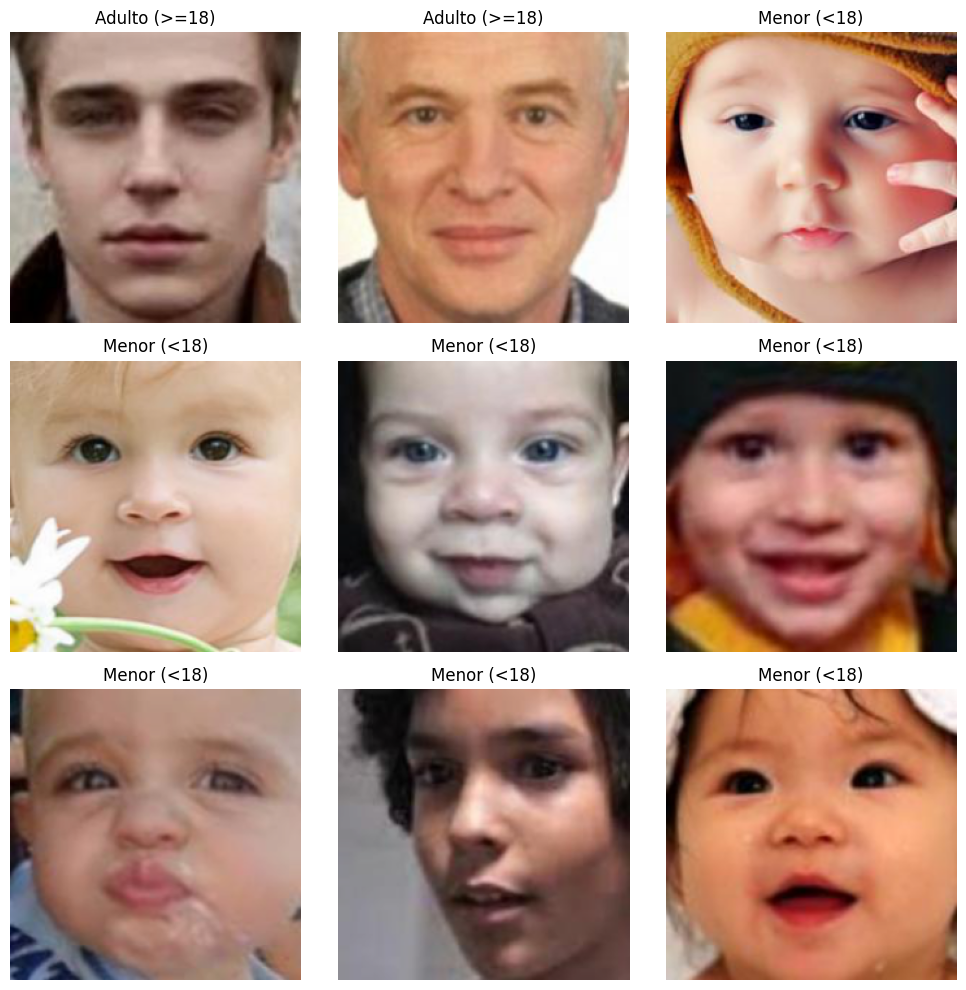

In [8]:
class_names = ["Adulto (>=18)", "Menor (<18)"]
mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])

plt.figure(figsize=(10, 10))
for i in range(9):
    img, label = full_ds[random.randint(0, len(full_ds) - 1)]
    img_show = img.numpy().transpose(1, 2, 0) * std + mean
    img_show = np.clip(img_show, 0, 1)
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(img_show)
    plt.title(class_names[int(label)])
    plt.axis("off")
plt.tight_layout(); plt.show()


Vamos a implementar la siguiente arquitectura:

- Imagen de entrada de 224x224
- 4 capas convolucionales consecutivas con kernel 3x3, padding `same` y activación ReLU. Número de filtros: 32, 64, 128 y 256, respectivamente.
- 1 capa de agrupación máxima (MaxPool 2x2) que reduzca la imagen a la mitad
- Convierte la salida a un vector con `GlobalAveragePooling`
- Capa densa oculta de 32 neuronas + ReLU
- Capa de salida de 1 neurona (sin sigmoid: `BCEWithLogitsLoss` la aplica internamente)

In [9]:
class CNNFromScratch(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(  3,  32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d( 32,  64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d( 64, 128, kernel_size=3, padding=1)
        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.pool  = nn.MaxPool2d(2)
        self.gap   = nn.AdaptiveAvgPool2d(1)
        self.fc1   = nn.Linear(256, 32)
        self.fc2   = nn.Linear( 32,  1)
        self.relu  = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.relu(self.conv2(x))
        x = self.relu(self.conv3(x))
        x = self.relu(self.conv4(x))
        x = self.pool(x)
        x = self.gap(x).flatten(1)
        x = self.relu(self.fc1(x))
        return self.fc2(x)


model_scratch = CNNFromScratch().to(device)

total     = sum(p.numel() for p in model_scratch.parameters())
trainable = sum(p.numel() for p in model_scratch.parameters() if p.requires_grad)
print(f"Parametros totales    : {total:,}")
print(f"Parametros entrenables: {trainable:,} ({100*trainable/total:.1f}%)")
print(model_scratch)


Parametros totales    : 396,673
Parametros entrenables: 396,673 (100.0%)
CNNFromScratch(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv4): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (gap): AdaptiveAvgPool2d(output_size=1)
  (fc1): Linear(in_features=256, out_features=32, bias=True)
  (fc2): Linear(in_features=32, out_features=1, bias=True)
  (relu): ReLU()
)


Compilamos el modelo (`BCEWithLogitsLoss` + `Adam`) y lo entrenamos durante 10 épocas, incluyendo
**ModelCheckpoint** (guarda el mejor `val_recall_minor`) y **EarlyStopping** (`patience=5`).

Dado que el objetivo del sistema es proteger la privacidad de menores, priorizamos el
**recall de la clase "Menor"** como métrica de checkpoint. Un falso negativo (menor no
detectado → no se pixela) es mucho más grave que un falso positivo (adulto pixelado
innecesariamente), por lo que maximizar recall minimiza ese riesgo.

In [ ]:
from sklearn.metrics import recall_score as sklearn_recall_score
from sklearn.metrics import precision_score as sklearn_precision_score


def binary_accuracy(logits, labels):
    preds = (torch.sigmoid(logits) > 0.5).float()
    return (preds == labels).float().mean().item()


def compute_recall_minor(all_preds, all_labels):
    return sklearn_recall_score(all_labels, all_preds, pos_label=1.0, zero_division=0)


def compute_precision_minor(all_preds, all_labels):
    return sklearn_precision_score(all_labels, all_preds, pos_label=1.0, zero_division=0)


def train_model(model, train_loader, val_loader, epochs, patience,
                lr, save_path, pos_weight_tensor=None):
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)
    optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5)

    history           = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": [],
                         "val_recall_minor": [], "val_precision_minor": []}
    best_val_recall   = 0.0
    best_val_loss     = float("inf")
    epochs_no_improve = 0

    n_train = len(train_loader.dataset)
    n_val   = len(val_loader.dataset)

    for epoch in range(1, epochs + 1):
        model.train()
        t_loss, t_acc = 0.0, 0.0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            logits = model(imgs).squeeze(1)
            loss   = criterion(logits, labels)
            loss.backward(); optimizer.step()
            t_loss += loss.item() * len(imgs)
            t_acc  += binary_accuracy(logits.detach(), labels) * len(imgs)

        model.eval()
        v_loss, v_acc = 0.0, 0.0
        v_preds_all, v_labels_all = [], []
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                logits = model(imgs).squeeze(1)
                v_loss += criterion(logits, labels).item() * len(imgs)
                v_acc  += binary_accuracy(logits, labels)  * len(imgs)
                preds = (torch.sigmoid(logits) > 0.5).float()
                v_preds_all.extend(preds.cpu().numpy())
                v_labels_all.extend(labels.cpu().numpy())

        train_loss = t_loss / n_train;  train_acc = t_acc / n_train
        val_loss   = v_loss / n_val;    val_acc   = v_acc / n_val
        val_recall = compute_recall_minor(v_preds_all, v_labels_all)
        val_prec   = compute_precision_minor(v_preds_all, v_labels_all)
        scheduler.step()

        history["train_loss"].append(train_loss); history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc);   history["val_acc"].append(val_acc)
        history["val_recall_minor"].append(val_recall)
        history["val_precision_minor"].append(val_prec)

        print(f"Epoca {epoch:2d}/{epochs}  train loss: {train_loss:.4f}  acc: {train_acc:.3f}  |  "
              f"val loss: {val_loss:.4f}  acc: {val_acc:.3f}  recall: {val_recall:.4f}  prec: {val_prec:.4f}")

        if val_recall > best_val_recall or (val_recall == best_val_recall and val_loss < best_val_loss):
            best_val_recall = val_recall; best_val_loss = val_loss
            torch.save(model.state_dict(), save_path)
            print(f"  -> Mejor modelo guardado (val recall={val_recall:.4f}  prec={val_prec:.4f}  loss={val_loss:.4f})")
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= patience:
            print(f"Early stopping en epoca {epoch} (sin mejora en {patience} epocas).")
            break

    print(f"Mejor val recall_minor: {best_val_recall:.4f}  |  Modelo: {save_path}")
    return history, best_val_recall


pos_weight = torch.tensor([n_adult / n_minor], dtype=torch.float32).to(device)

history_scratch, recall_scratch = train_model(
    model_scratch, train_loader, val_loader,
    epochs=EPOCHS, patience=PATIENCE, lr=LR,
    save_path=os.path.join(PATH_MODELS, "age_scratch.pth"),
    pos_weight_tensor=pos_weight,
)

Epoca  1/10  train loss: 0.7835  acc: 0.575  |  val loss: 0.7864  acc: 0.543  recall: 0.8171  prec: 0.4516
  -> Mejor modelo guardado (val recall=0.8171  prec=0.4516  loss=0.7864)
Epoca  2/10  train loss: 0.7683  acc: 0.613  |  val loss: 0.7749  acc: 0.597  recall: 0.7487  prec: 0.4880
Epoca  3/10  train loss: 0.7603  acc: 0.623  |  val loss: 0.7424  acc: 0.675  recall: 0.5908  prec: 0.5809
Epoca  4/10  train loss: 0.7618  acc: 0.622  |  val loss: 0.7724  acc: 0.568  recall: 0.7947  prec: 0.4671
Epoca  5/10  train loss: 0.7531  acc: 0.626  |  val loss: 0.7639  acc: 0.598  recall: 0.7658  prec: 0.4891
Epoca  6/10  train loss: 0.7516  acc: 0.634  |  val loss: 0.7655  acc: 0.605  recall: 0.7592  prec: 0.4949
Early stopping en epoca 6 (sin mejora en 5 epocas).
Mejor val recall_minor: 0.8171  |  Modelo: models\age_scratch.pth


Mostramos tres gráficas: pérdidas (train/val), exactitud (train/val) del modelo y recall.

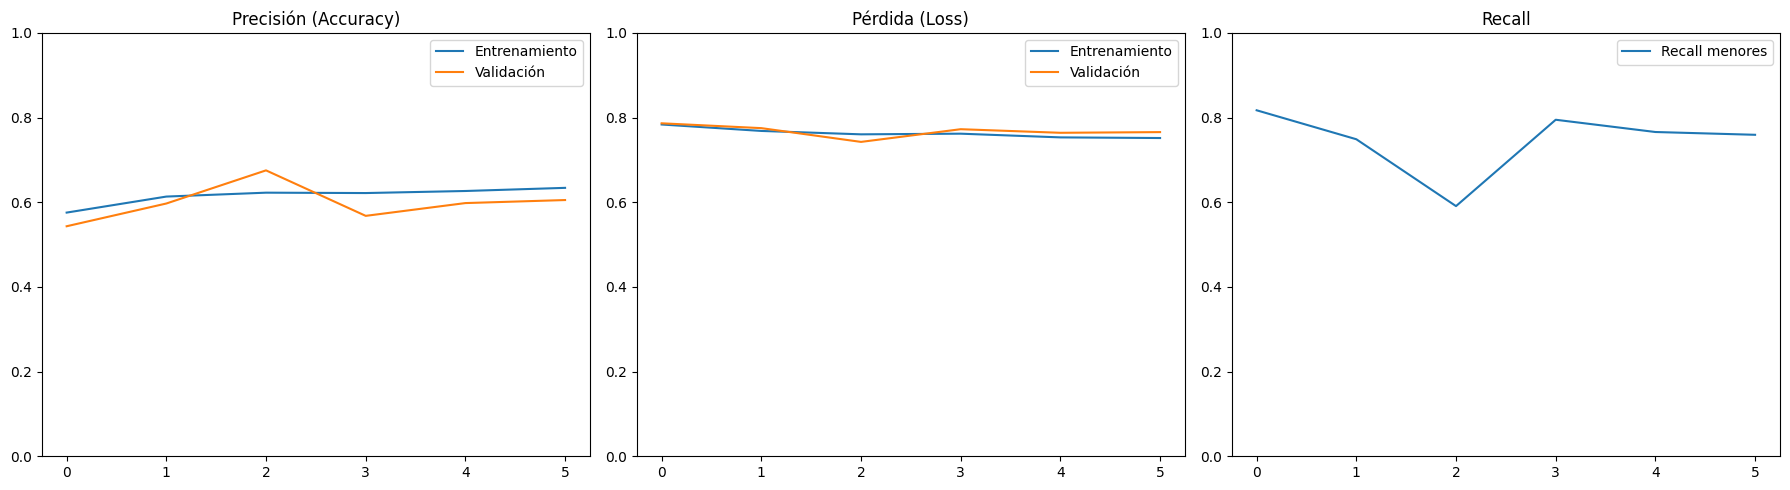

In [37]:
def plot_history(history):
    epochs_range = range(len(history["train_acc"]))
    plt.figure(figsize=(18, 5))

    plt.subplot(1, 3, 1)
    plt.plot(epochs_range, history["train_acc"], label="Entrenamiento")
    plt.plot(epochs_range, history["val_acc"], label="Validación")
    plt.ylim(0, 1); plt.title("Precisión (Accuracy)"); plt.legend()

    plt.subplot(1, 3, 2)
    plt.plot(epochs_range, history["train_loss"], label="Entrenamiento")
    plt.plot(epochs_range, history["val_loss"], label="Validación")
    plt.ylim(0, 1); plt.title("Pérdida (Loss)"); plt.legend()

    plt.subplot(1, 3, 3)
    plt.plot(epochs_range, history["val_recall_minor"], label="Recall menores")
    plt.ylim(0, 1); plt.title("Recall"); plt.legend()

    plt.tight_layout(); plt.show()

plot_history(history_scratch)

# 6

Entrenamos de nuevo el modelo con **transferencia de conocimiento** con **ResNet-50**
preentrenado en ImageNet.

- Congelamos toda la base convolucional
- Descongelamos solo `layer4` para fine-tuning
- Cabeza de clasificación: `Linear(2048, 256) → ReLU → Dropout(0.3) → Linear(256, 1)`

In [12]:
def get_resnet_model():
    model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
    for param in model.parameters():
        param.requires_grad = False
    for param in model.layer4.parameters():
        param.requires_grad = True
    model.fc = nn.Sequential(
        nn.Linear(model.fc.in_features, 256),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(256, 1),
    )
    return model.to(device)


model_transfer = get_resnet_model()

total     = sum(p.numel() for p in model_transfer.parameters())
trainable = sum(p.numel() for p in model_transfer.parameters() if p.requires_grad)
print(f"Parametros totales    : {total:,}")
print(f"Parametros entrenables: {trainable:,} ({100*trainable/total:.1f}%)")

history_transfer, recall_transfer = train_model(
    model_transfer, train_loader, val_loader,
    epochs=EPOCHS, patience=PATIENCE, lr=LR,
    save_path=os.path.join(PATH_MODELS, "age_transfer.pth"),
    pos_weight_tensor=pos_weight,
)

Parametros totales    : 24,032,833
Parametros entrenables: 15,489,537 (64.5%)
Epoca  1/10  train loss: 0.3499  acc: 0.854  |  val loss: 0.2555  acc: 0.923  recall: 0.8868  prec: 0.9133
  -> Mejor modelo guardado (val recall=0.8868  prec=0.9133  loss=0.2555)
Epoca  2/10  train loss: 0.1261  acc: 0.963  |  val loss: 0.2261  acc: 0.925  recall: 0.9211  prec: 0.8906
  -> Mejor modelo guardado (val recall=0.9211  prec=0.8906  loss=0.2261)
Epoca  3/10  train loss: 0.0637  acc: 0.983  |  val loss: 0.2437  acc: 0.931  recall: 0.9145  prec: 0.9097
Epoca  4/10  train loss: 0.0345  acc: 0.992  |  val loss: 0.2348  acc: 0.931  recall: 0.9145  prec: 0.9085
Epoca  5/10  train loss: 0.0156  acc: 0.996  |  val loss: 0.2677  acc: 0.938  recall: 0.9039  prec: 0.9334
Epoca  6/10  train loss: 0.0124  acc: 0.997  |  val loss: 0.3014  acc: 0.934  recall: 0.8829  prec: 0.9424
Epoca  7/10  train loss: 0.0101  acc: 0.997  |  val loss: 0.2812  acc: 0.938  recall: 0.9092  prec: 0.9288
Early stopping en epoca 7 (

Mostramos 3 gráficas:
- Curvas de pérdida (entrenamiento y validación) del modelo del apartado 5
- Curvas de exactitud (entrenamiento y validación) del modelo del apartado 5
- Curvas de exactitud en validación del apartado 3 vs apartado 5

¿Qué solución ofrece mejores resultados para la detección de menores?

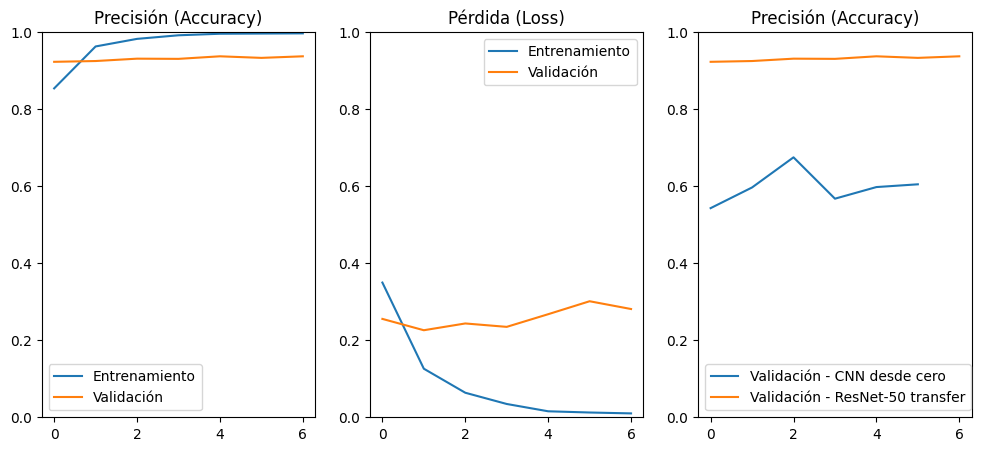

Mejor val recall_minor — CNN desde cero  : 0.8171
Mejor val recall_minor — ResNet-50 (TL)  : 0.9211


In [38]:
def plot_compare(h1, h2, n1="Modelo 1", n2="Modelo 2"):
    acc1 = h2["train_acc"]
    val_acc1 = h2["val_acc"]
    loss1 = h2["train_loss"]
    val_loss1 = h2["val_loss"]
    epochs_range1 = range(len(acc1))

    val_acc2 = h1["val_acc"]
    epochs_range2 = range(len(val_acc2))

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 3, 1)
    plt.plot(epochs_range1, acc1, label="Entrenamiento")
    plt.plot(epochs_range1, val_acc1, label="Validación")
    plt.ylim(0, 1)
    plt.title("Precisión (Accuracy)")
    plt.legend()

    plt.subplot(1, 3, 2)
    plt.plot(epochs_range1, loss1, label="Entrenamiento")
    plt.plot(epochs_range1, val_loss1, label="Validación")
    plt.ylim(0, 1)
    plt.title("Pérdida (Loss)")
    plt.legend()

    plt.subplot(1, 3, 3)
    plt.plot(epochs_range2, val_acc2, label=f"Validación - {n1}")
    plt.plot(epochs_range1, val_acc1, label=f"Validación - {n2}")
    plt.ylim(0, 1)
    plt.title("Precisión (Accuracy)")
    plt.legend()

    plt.show()


plot_compare(history_scratch, history_transfer, "CNN desde cero", "ResNet-50 transfer")
print(f"Mejor val recall_minor — CNN desde cero  : {recall_scratch:.4f}")
print(f"Mejor val recall_minor — ResNet-50 (TL)  : {recall_transfer:.4f}")

Mostramos dos gráficas con el recall de los menores en validación.

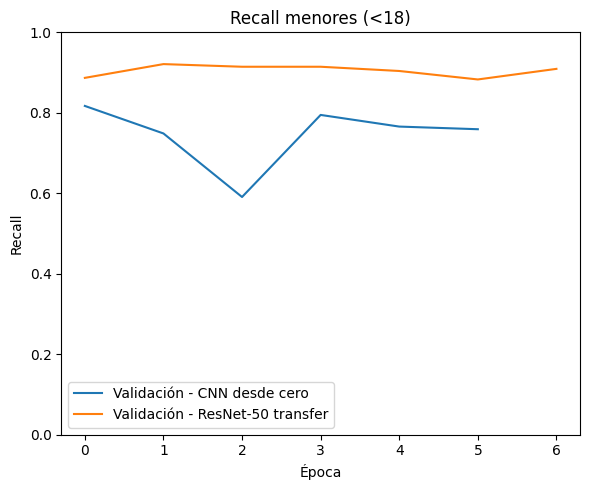

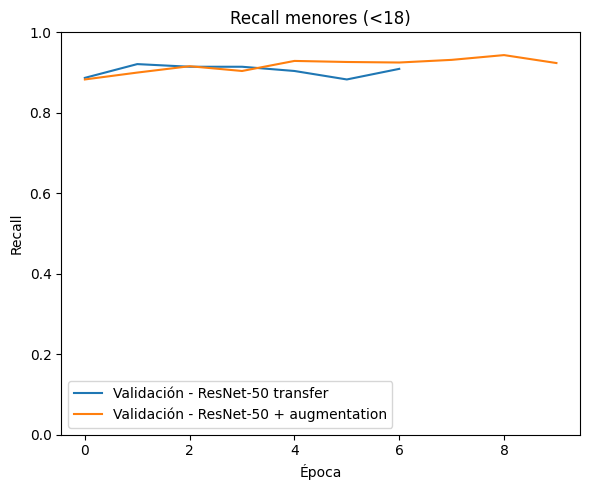

In [40]:
def plot_compare_recall(h1, h2, n1="Modelo 1", n2="Modelo 2"):
    epochs_range1 = range(len(h1["val_recall_minor"]))
    epochs_range2 = range(len(h2["val_recall_minor"]))
    
    plt.figure(figsize=(6, 5))
    plt.plot(epochs_range1, h1["val_recall_minor"], label=f"Validación - {n1}")
    plt.plot(epochs_range2, h2["val_recall_minor"], label=f"Validación - {n2}")
    
    plt.ylim(0, 1)
    plt.xlabel("Época")
    plt.ylabel("Recall")
    plt.title("Recall menores (<18)")
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_compare_recall(history_scratch, history_transfer, 
                    "CNN desde cero", "ResNet-50 transfer")

plot_compare_recall(history_transfer, history_aug, 
                    "ResNet-50 transfer", "ResNet-50 + augmentation")

# 7

Entrenamos de nuevo el modelo introduciendo **aumento de datos** con las siguientes transformaciones:

- Cambios de brillo y contraste aleatorio, con un 50% de probabilidad
- Uso del filtro CLAHE, con un 20% de probabilidad
- Rotaciones aleatorias, con un máximo de 10° y una probabilidad del 30%
- Giros horizontales con un 10% de probabilidad

Mantenemos transferencia de conocimiento (ResNet-50), que es la
que mejores resultados ha ofrecido en el apartado 6.

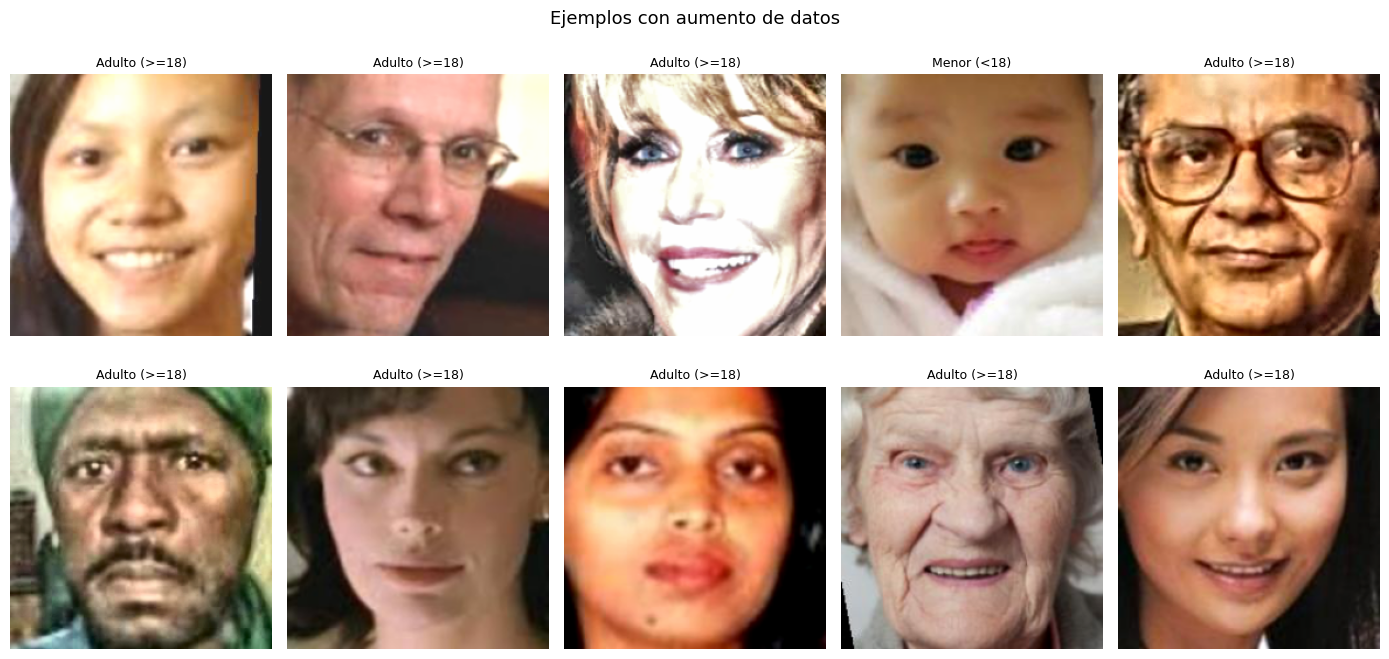

In [14]:
train_tf_aug = A.Compose([
    A.RandomBrightnessContrast(p=0.5),
    A.CLAHE(p=0.2),
    A.Rotate(limit=10, p=0.3),
    A.HorizontalFlip(p=0.1),
    A.Resize(*IMG_SIZE),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

full_ds_aug         = FaceAgeDataset(DATASET_ROOT, transform=train_tf_aug)
train_ds_aug, _     = random_split(full_ds_aug, [train_size, val_size],
                                    generator=torch.Generator().manual_seed(42))
train_loader_aug    = DataLoader(train_ds_aug, batch_size=BATCH_SIZE, sampler=sampler, num_workers=0)

fig, axes = plt.subplots(2, 5, figsize=(14, 7))
for i in range(10):
    img, label = train_ds_aug[random.randint(0, len(train_ds_aug) - 1)]
    img_show = img.numpy().transpose(1, 2, 0) * std + mean
    img_show = np.clip(img_show, 0, 1)
    ax = axes[i // 5, i % 5]
    ax.imshow(img_show)
    ax.set_title(class_names[int(label)], fontsize=9)
    ax.axis("off")
plt.suptitle("Ejemplos con aumento de datos", fontsize=13)
plt.tight_layout(h_pad=2.0)
plt.show()

Epoca  1/10  train loss: 0.3841  acc: 0.837  |  val loss: 0.2358  acc: 0.927  recall: 0.8829  prec: 0.9268
  -> Mejor modelo guardado (val recall=0.8829  prec=0.9268  loss=0.2358)
Epoca  2/10  train loss: 0.2029  acc: 0.932  |  val loss: 0.2082  acc: 0.934  recall: 0.9000  prec: 0.9268
  -> Mejor modelo guardado (val recall=0.9000  prec=0.9268  loss=0.2082)
Epoca  3/10  train loss: 0.1477  acc: 0.955  |  val loss: 0.1961  acc: 0.937  recall: 0.9158  prec: 0.9206
  -> Mejor modelo guardado (val recall=0.9158  prec=0.9206  loss=0.1961)
Epoca  4/10  train loss: 0.1131  acc: 0.963  |  val loss: 0.1878  acc: 0.940  recall: 0.9039  prec: 0.9398
Epoca  5/10  train loss: 0.0897  acc: 0.974  |  val loss: 0.1810  acc: 0.947  recall: 0.9289  prec: 0.9339
  -> Mejor modelo guardado (val recall=0.9289  prec=0.9339  loss=0.1810)
Epoca  6/10  train loss: 0.0800  acc: 0.975  |  val loss: 0.1708  acc: 0.947  recall: 0.9263  prec: 0.9362
Epoca  7/10  train loss: 0.0651  acc: 0.980  |  val loss: 0.1748  

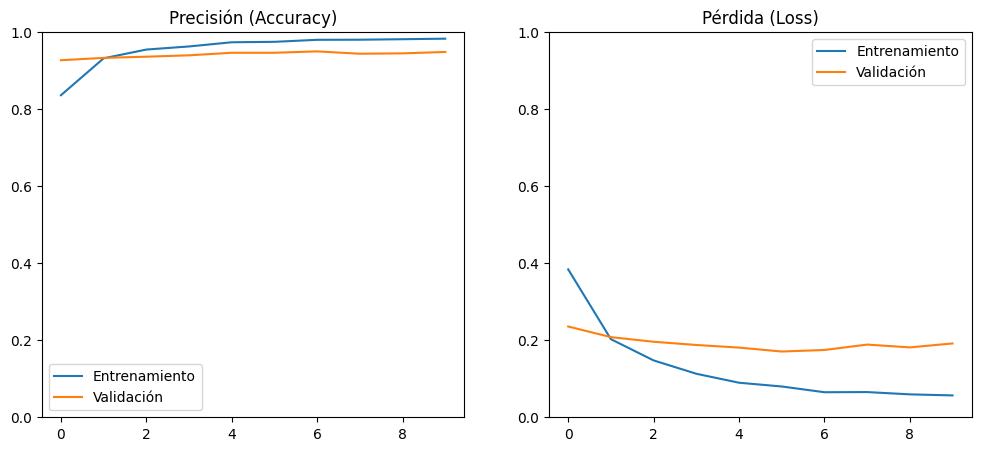


CNN desde cero          : 0.8171
ResNet-50 transferencia : 0.9211
ResNet-50 + augmentation: 0.9434


In [15]:
model_aug = get_resnet_model()

history_aug, recall_aug = train_model(
    model_aug, train_loader_aug, val_loader,
    epochs=EPOCHS, patience=PATIENCE, lr=LR,
    save_path=os.path.join(PATH_MODELS, "age_aug.pth"),
    pos_weight_tensor=pos_weight,
)

plot_history(history_aug, "(ResNet-50 + aumento de datos)")

print()
print(f"CNN desde cero          : {recall_scratch:.4f}")
print(f"ResNet-50 transferencia : {recall_transfer:.4f}")
print(f"ResNet-50 + augmentation: {recall_aug:.4f}")

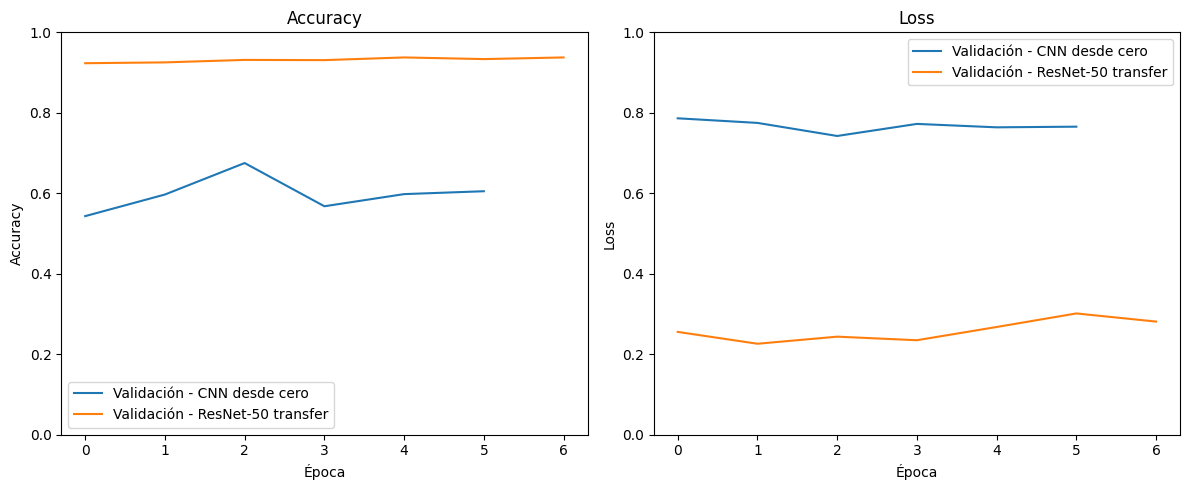

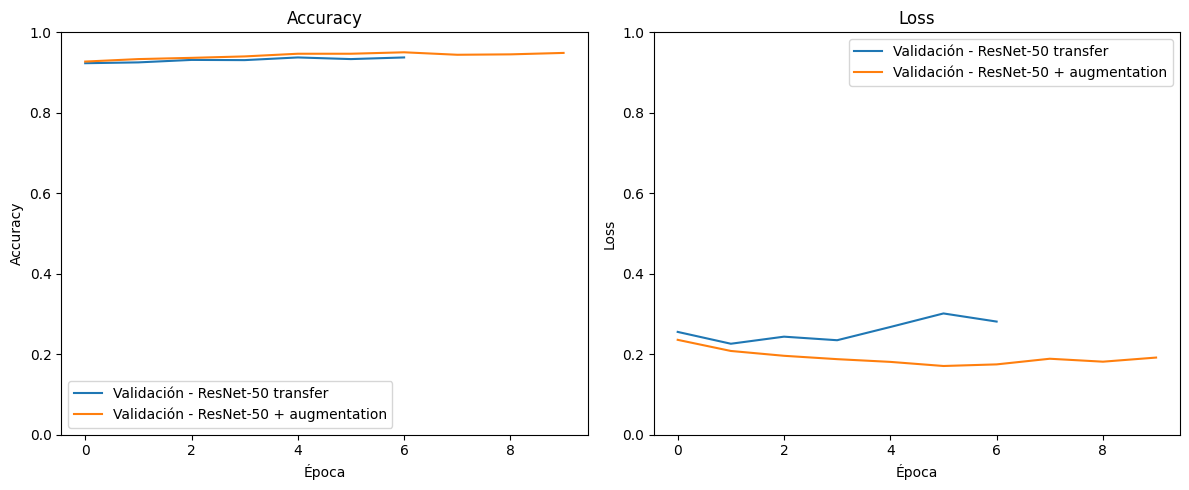

In [44]:
def plot_compare_acc_loss(h1, h2, n1="Modelo 1", n2="Modelo 2"):
    epochs_range1 = range(len(h1["val_acc"]))
    epochs_range2 = range(len(h2["val_acc"]))

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].plot(epochs_range1, h1["val_acc"], label=f"Validación - {n1}")
    axes[0].plot(epochs_range2, h2["val_acc"], label=f"Validación - {n2}")
    axes[0].set_ylim(0, 1)
    axes[0].set_xlabel("Época")
    axes[0].set_ylabel("Accuracy")
    axes[0].set_title("Accuracy")
    axes[0].legend()

    axes[1].plot(epochs_range1, h1["val_loss"], label=f"Validación - {n1}")
    axes[1].plot(epochs_range2, h2["val_loss"], label=f"Validación - {n2}")
    axes[1].set_ylim(0, 1)
    axes[1].set_xlabel("Época")
    axes[1].set_ylabel("Loss")
    axes[1].set_title("Loss")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

plot_compare_acc_loss(history_scratch, history_transfer,
                      "CNN desde cero", "ResNet-50 transfer")

plot_compare_acc_loss(history_transfer, history_aug,
                      "ResNet-50 transfer", "ResNet-50 + augmentation")

# 8

Con el mejor modelo seleccionado, implementamos un método de inferencia que, dada una
imagen de cara, prediga si es **menor (<18)** o **adulto (>=18)** e imprima la clase
predicha y su score.

In [16]:
from sklearn.metrics import (confusion_matrix,
                             precision_recall_curve, auc,
                             f1_score as sklearn_f1_score)
import seaborn as sns

mejores = {
    "scratch":  (recall_scratch,  CNNFromScratch,    os.path.join(PATH_MODELS, "age_scratch.pth")),
    "transfer": (recall_transfer, get_resnet_model,  os.path.join(PATH_MODELS, "age_transfer.pth")),
    "aug":      (recall_aug,      get_resnet_model,  os.path.join(PATH_MODELS, "age_aug.pth")),
}
nombre_mejor = max(mejores, key=lambda k: mejores[k][0])
recall_best, build_fn, path_best = mejores[nombre_mejor]
print(f"Mejor modelo: {nombre_mejor} (val recall_minor={recall_best:.4f})  -> {path_best}")

best_model = build_fn().to(device) if nombre_mejor == "scratch" else build_fn()
best_model.load_state_dict(torch.load(path_best, map_location=device))
best_model.eval()

final_path = "age_model.pth"
torch.save(best_model.state_dict(), final_path)
print(f"Modelo final copiado a: {final_path}")

Mejor modelo: aug (val recall_minor=0.9434)  -> models\age_aug.pth
Modelo final copiado a: age_model.pth


Umbral guardado en: age_threshold.json
Accuracy         : 0.9453
PR-AUC           : 0.9847
Recall           : 0.9487


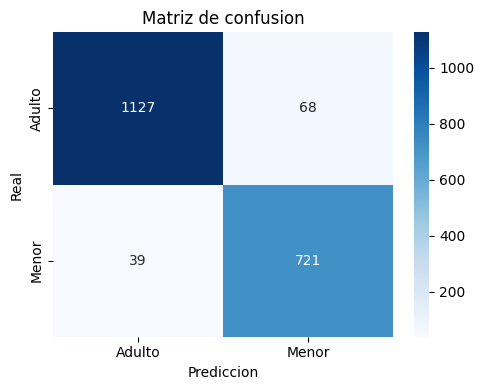

In [22]:
all_scores, all_labels = [], []
with torch.no_grad():
    for imgs, labels in val_loader:
        logits  = best_model(imgs.to(device)).squeeze(1)
        scores  = torch.sigmoid(logits).cpu().numpy()
        all_scores.extend(scores)
        all_labels.extend(labels.numpy())

all_scores = np.array(all_scores)
all_labels = np.array(all_labels)

optimal_threshold = 0.45

import json as _json
threshold_path = "age_threshold.json"
with open(threshold_path, "w") as _f:
    _json.dump({"threshold": float(optimal_threshold)}, _f)
print(f"Umbral guardado en: {threshold_path}")

all_preds = (all_scores > optimal_threshold).astype(float)

precision_curve, recall_curve, _ = precision_recall_curve(all_labels, all_scores)
acc = (all_preds == all_labels).mean()
pr_auc = auc(recall_curve, precision_curve)
recall_minor = sklearn_recall_score(all_labels, all_preds, pos_label=1.0, zero_division=0)

print(f"Accuracy         : {acc:.4f}")
print(f"PR-AUC           : {pr_auc:.4f}")
print(f"Recall           : {recall_minor:.4f}")

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Adulto", "Menor"],
            yticklabels=["Adulto", "Menor"])
plt.title("Matriz de confusion")
plt.ylabel("Real"); plt.xlabel("Prediccion")
plt.tight_layout(); plt.show()

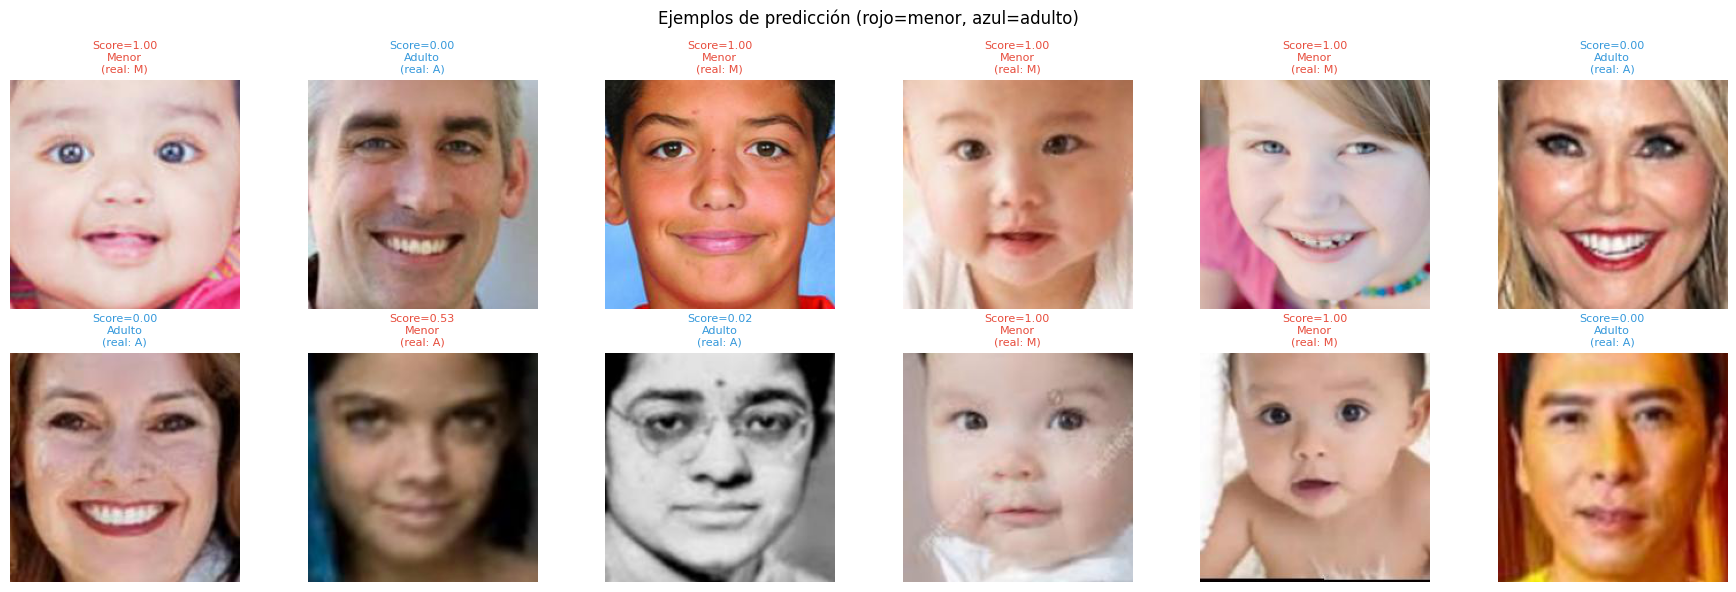

In [18]:
from torchvision import transforms as T

infer_tf = T.Compose([
    T.Resize(IMG_SIZE),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


THRESHOLD = optimal_threshold


def predecir(img_path: str) -> tuple:
    img    = Image.open(img_path).convert("RGB")
    tensor = infer_tf(img).unsqueeze(0).to(device)
    with torch.no_grad():
        logit = best_model(tensor).squeeze().item()
    score    = torch.sigmoid(torch.tensor(logit)).item()
    es_menor = score > THRESHOLD
    return round(score, 4), es_menor


sample_indices = random.sample(range(len(val_ds)), 12)
fig, axes = plt.subplots(2, 6, figsize=(18, 6))
for ax, idx in zip(axes.flat, sample_indices):
    path, true_label = full_ds.samples[val_ds.indices[idx]]
    img             = Image.open(path).convert("RGB")
    score, es_menor = predecir(path)
    color  = "#e74c3c" if es_menor else "#3498db"
    titulo = f"Score={score:.2f}\n{'Menor' if es_menor else 'Adulto'}\n(real: {'M' if true_label==1 else 'A'})"
    ax.imshow(img)
    ax.set_title(titulo, fontsize=8, color=color)
    ax.axis("off")
plt.suptitle("Ejemplos de predicción (rojo=menor, azul=adulto)", fontsize=12)
plt.tight_layout(); plt.show()
